# Tracking Habitat and Land Change from Space

Satellites photograph the same ground over and over. If we can teach a model to read those tiles and label what is on the ground, we get a running record of how a landscape changes over time — where forest gives way to cropland, where water shrinks or spreads, where urban areas push outward. That record is the raw material for conservation work: it tells you *where* habitat is being lost and *how fast*.

This notebook tells one continuous story: we train a small image classifier to sort satellite tiles into four **land cover / land use** classes and then watch it work.

- **forest** — tree-covered land
- **water** — lakes, rivers, sea
- **cropland** — cultivated fields
- **urban** — built-up, developed land

We use a small subset of the public **EuroSAT** dataset (Sentinel-2 tiles), a compact PyTorch CNN trained from scratch, and an Amazon SageMaker **managed training job** launched with the SageMaker Python SDK v3 `ModelTrainer`. The goal is a clear, working, end-to-end run — not state-of-the-art accuracy.

## Where Kiro helps

Kiro works alongside you right here inside SageMaker JupyterLab. Along the way it can:

- **Generate the training script** (`train.py`) — the CNN, the training loop, and the SageMaker input/output wiring.
- **Wire up the `ModelTrainer`** — filling in the training image, source code, compute, and hyperparameters correctly.
- **Explain SageMaker concepts** — what the execution role is for, why data goes to S3, and what a managed training job actually does.

The notebook runs top to bottom. Each code cell is introduced by a short note on *why* the step exists before the *how*.

## 1. Set up the SageMaker session

Before we can launch anything, SageMaker needs two things, and it is worth being explicit about why:

- **An execution role (IAM role).** A managed training job runs on infrastructure that AWS spins up on your behalf — separate from this notebook. That infrastructure needs permission to read your training data from S3 and to write the model artifact back. The **execution role** carries those permissions. Inside SageMaker JupyterLab we can resolve the role the environment already provides, so there is nothing to create by hand.
- **An S3 bucket.** The training job cannot read files from this notebook's local disk; it reads from Amazon S3. We use SageMaker's **default bucket** to stage the training data and to receive the model artifact, so no bucket setup is required.

The cell below creates the session, resolves the role, and picks the default bucket, then prints both so you can see exactly what will be used.

In [1]:
from sagemaker.core.helper.session_helper import Session, get_execution_role

# A Session ties together the AWS clients SageMaker needs (S3, SageMaker, etc.).
session = Session()

# Resolve the execution role the JupyterLab environment already provides.
# This role is what the managed training job will assume to reach S3.
role = get_execution_role()

# Use the account/region default bucket to stage data and receive artifacts.
bucket = session.default_bucket()

# The region is needed to resolve the managed PyTorch training image later.
region = session.boto_region_name

print("Execution role:", role)
print("Default bucket: ", bucket)
print("Region:         ", region)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Execution role: arn:aws:iam::608580452093:role/service-role/AmazonSageMaker-ExecutionRole-20260210T153980
Default bucket:  sagemaker-us-east-1-608580452093
Region:          us-east-1


## 2. Prepare a small EuroSAT subset

EuroSAT ships ten land-use categories; we only need four. `data_prep` downloads EuroSAT once (torchvision caches it), maps four source categories onto our target classes (Forest→forest, SeaLake→water, AnnualCrop→cropland, Industrial→urban), and caps the number of images per class so the download, upload, and training all stay quick.

It also sets aside a few **held-out** tiles per class *in memory*. Those tiles are never written for training and never uploaded — we keep them for the "does it actually work?" check after training, on tiles the model has not seen.

When prep finishes we print the per-class counts so you can see the subset composition.

In [2]:
import data_prep

# Backed by torchvision; the download happens lazily on first use.
image_source = data_prep.load_eurosat_source()

# Build the ImageFolder-style subset under ./data and keep the held-out tiles.
data_dir = "data"
counts, held_out = data_prep.prepare_subset(image_source, out_dir=data_dir)

print("Images prepared per class:")
for class_name, n in counts.items():
    print(f"  {class_name:>8}: {n}")
print("Total images:", sum(counts.values()))
print("Held-out tiles (kept in memory, not uploaded):", len(held_out))

100%|██████████| 94.3M/94.3M [00:00<00:00, 97.1MB/s]


Images prepared per class:
    forest: 200
     water: 200
  cropland: 200
     urban: 200
Total images: 800
Held-out tiles (kept in memory, not uploaded): 8


## 3. Preview a few sample tiles

Before training, it helps to *see* what the model learns from. The grid below shows a handful of tiles per class, each titled with its label. This runs purely in the notebook on the images we just wrote locally — it does not touch the training job at all.

[09/29/26 23:41:19] INFO     generated new fontManager                                         ]8;id=8737787;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=8737788;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py#1639\1639]8;;\

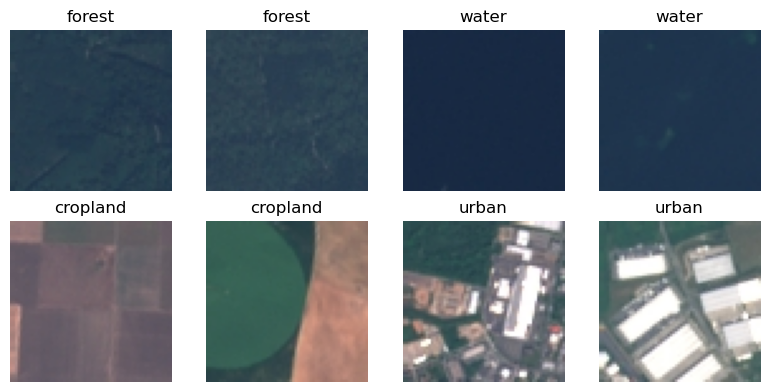

In [3]:
import os
from PIL import Image
from viz import show_sample_grid
from data_prep import TARGET_CLASSES

# Grab the first couple of tiles from each class directory for the preview.
samples = []
for class_name in TARGET_CLASSES:
    class_dir = os.path.join(data_dir, class_name)
    file_names = sorted(os.listdir(class_dir))[:2]
    for file_name in file_names:
        img = Image.open(os.path.join(class_dir, file_name)).convert("RGB")
        samples.append((img, class_name))

show_sample_grid(samples)

## 4. Upload the subset to S3

The managed training job reads its data from S3, not from this notebook's disk, so we upload the prepared subset to the default bucket under a demo-scoped prefix. The returned S3 URI becomes the training job's **input channel**.

Note the held-out tiles stay in memory — we deliberately do **not** upload them, so the post-training check runs on tiles the model never trained on.

In [4]:
import os
import boto3

# The v3 Session does not expose upload_data, so upload each file with boto3.
# Walk ./data and mirror it under s3://<bucket>/satellite-land-cover-demo/data.
s3 = boto3.client("s3")
key_prefix = "satellite-land-cover-demo/data"

for root, _dirs, files in os.walk(data_dir):
    for file_name in files:
        local_path = os.path.join(root, file_name)
        # Preserve the <class>/<file> layout relative to data_dir.
        rel_path = os.path.relpath(local_path, data_dir)
        s3_key = f"{key_prefix}/" + rel_path.replace(os.sep, "/")
        s3.upload_file(local_path, bucket, s3_key)

s3_data_uri = f"s3://{bucket}/{key_prefix}"
print("Training data uploaded to:", s3_data_uri)

Training data uploaded to: s3://sagemaker-us-east-1-608580452093/satellite-land-cover-demo/data


## 5. Configure the ModelTrainer

SDK v3 removed the v2 `sagemaker.pytorch.PyTorch` estimator; managed training is launched with `ModelTrainer` instead. We describe the job in a few small pieces:

- **`training_image`** — a managed PyTorch training container resolved with `image_uris.retrieve` (framework `pytorch`, version `2.2`, `py310`), so `train.py` runs against a known PyTorch.
- **`source_code=SourceCode(source_dir=".", entry_script="train.py")`** — the script to run and the folder to ship to the training container (so `train.py` and its neighbors go along).
- **`compute=Compute(instance_type="ml.m5.large", instance_count=1)`** — a small, single CPU instance. Our model and subset are tiny, so CPU is plenty.
- **`role`** — the execution role from step 1; the job assumes it to reach S3.
- **`hyperparameters`** — passed to `train.py` as command-line args; kept small (3 epochs, batch size 32) to keep the job short.
- **`output_data_config`** — where SageMaker writes the resulting `model.tar.gz`.

In [5]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import SourceCode, Compute, OutputDataConfig
from sagemaker.core import image_uris

instance_type = "ml.m5.large"

# Resolve the managed PyTorch training container image for this region.
training_image = image_uris.retrieve(
    framework="pytorch",
    region=region,
    version="2.2",
    py_version="py310",
    instance_type=instance_type,
    image_scope="training",
)

# Ship train.py (and its neighbors) as the entry script.
source_code = SourceCode(source_dir=".", entry_script="train.py")

# A small, single CPU instance is plenty for this tiny model and subset.
compute = Compute(instance_type=instance_type, instance_count=1)

model_trainer = ModelTrainer(
    training_image=training_image,
    role=role,
    source_code=source_code,
    compute=compute,
    hyperparameters={
        "epochs": 3,
        "batch-size": 32,
    },
    output_data_config=OutputDataConfig(s3_output_path=f"s3://{bucket}/"),
)

print("ModelTrainer configured with entry script:", source_code.entry_script)

[09/29/26 23:42:15] INFO     SageMaker session not provided. Using default Session.                  ]8;id=8737795;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=8737796;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#61\61]8;;\

                    INFO     Base name not provided. Using default name:                             ]8;id=8737802;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=8737803;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#90\90]8;;\
                             pytorch-training-job                                                                  

                    INFO     StoppingCondition not provided. Using default:                         ]8;id=8737809;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=8737810;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#128\128]8;;\
                             max_runtime_in_seconds=3600 max_wait_time_in_seconds=None                             
                             max_pending_time_in_seconds=None                                                      

                    INFO     OutputDataConfig compression type not provided. Using default:         ]8;id=8737816;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=8737817;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/defaults.py#165\165]8;;\
                             GZIP                                                                                  

                    INFO     Training image URI:                                               ]8;id=8737824;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=8737825;file:///opt/conda/lib/python3.12/site-packages/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.2                     
                             -cpu-py310                                                                            

ModelTrainer configured with entry script: train.py


## 6. Launch the managed training job

Calling `train()` hands everything to SageMaker: it provisions the instance, pulls the container, ships our code, streams the S3 input channel in, runs `train.py`, and collects the model artifact. Training runs on that managed infrastructure — **not** inside this notebook process. We pass a single `InputData` channel named `training`, which surfaces as `SM_CHANNEL_TRAINING` inside `train.py`.

Success and failure information both come from the training job description. On success we read the artifact location from `describe_training_job(...)["ModelArtifacts"]["S3ModelArtifacts"]`. If the job fails, `train()` raises; we catch it and read the SageMaker **FailureReason** straight from the job description so you see *why* it failed rather than a bare traceback.

In [ ]:
import boto3
from sagemaker.train.configs import InputData
from reporting import extract_failure_reason

sm = boto3.client("sagemaker")
model_data_uri = None

try:
    model_trainer.train(
        input_data_config=[
            InputData(channel_name="training", data_source=s3_data_uri),
        ]
    )
    job_name = model_trainer._latest_training_job.training_job_name
    desc = sm.describe_training_job(TrainingJobName=job_name)
    model_data_uri = desc["ModelArtifacts"]["S3ModelArtifacts"]
    print("Training complete.")
    print("Model artifact:", model_data_uri)
except Exception as error:
    print("Training job raised an exception:", error)
    # Read the training job description from SageMaker (this part needs AWS),
    # then extract the failure reason with the pure, testable helper.
    job_name = model_trainer._latest_training_job.training_job_name
    desc = sm.describe_training_job(TrainingJobName=job_name)
    print("SageMaker FailureReason:", extract_failure_reason(desc))

[09/29/26 23:42:31] INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=8737832;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=8737833;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py#322\322]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

## 7. Load the trained model back into the notebook

To *see* the model work, we bring its artifact back locally. We download `model.tar.gz` from the artifact URI reported by the training job description, extract `model.pth`, rebuild the same `SmallCNN` architecture, and load the saved weights. This is purely for visualization — it reads the finished artifact and does not change the training job in any way.

The S3 download is injected as a small `download_fn` so the reusable helper in `viz.py` stays free of any hard SageMaker dependency.

In [ ]:
import boto3
from urllib.parse import urlparse
from viz import load_trained_model


def download_fn(model_data_uri, local_tar_path):
    """Fetch model.tar.gz from S3 into a local path (injected into viz)."""
    parsed = urlparse(model_data_uri)
    src_bucket = parsed.netloc
    key = parsed.path.lstrip("/")
    boto3.client("s3").download_file(src_bucket, key, local_tar_path)
    return local_tar_path


model = load_trained_model(model_data_uri, download_fn)
print("Model loaded and set to eval mode:", type(model).__name__)

## 8. Predicted vs. actual on held-out tiles

Finally, the payoff. We run the loaded model on the held-out tiles we set aside during prep — tiles it never trained on — and draw a grid annotating each with its **predicted** and **actual** label. This is the visible "it works" check, and like the earlier preview it runs entirely on local images without touching the training job.

In [ ]:
from torchvision import transforms
from viz import show_prediction_grid

# EuroSAT tiles are 64x64 RGB; Resize keeps any off-size tile at the shape the
# model expects, and ToTensor produces the (3, 64, 64) tensor.
to_tensor = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

show_prediction_grid(model, held_out, to_tensor)